# Fracture Classification: YOLOv8 Backbone + PCA + SVM
Uses the pretrained YOLOv8s backbone as a frozen feature extractor,
PCA for dimensionality reduction, and SVM (RBF kernel) for binary classification
(fractured vs non-fractured).

## 1. Setup

In [1]:
!uv pip install ultralytics scikit-learn tqdm matplotlib -q

In [2]:
import torch
import numpy as np
from pathlib import Path
from PIL import Image, ImageFile
import torchvision.transforms as T
from ultralytics import YOLO
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import random

ImageFile.LOAD_TRUNCATED_IMAGES = True

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

PyTorch: 2.10.0
CUDA available: False
Using device: cpu


In [3]:
# --- Config ---
IMAGES_DIR = Path("datasets/images")   # contains Fractured/, Non_fractured/
DIST_DIR   = Path("Distribution")      # train.csv, valid.csv, test.csv
MODEL_PATH = "../weights/yolov8_localization_fractureAtlas.pt"
IMGSZ      = 224
N_PCA      = 128                       # more components = more variance retained
SEED       = 42

## 2. Load Dataset Paths & Labels

In [4]:
def load_csv_ids(csv_path: Path) -> set:
    ids = set()
    with open(csv_path) as f:
        for line in f:
            line = line.strip()
            if not line or line == "image_id":
                continue
            ids.add(line)
    return ids


# --- Fractured splits (from CSVs) ---
frac_dir = IMAGES_DIR / "Fractured"

train_ids = load_csv_ids(DIST_DIR / "train.csv")
val_ids   = load_csv_ids(DIST_DIR / "valid.csv")
test_ids  = load_csv_ids(DIST_DIR / "test.csv")

frac_train = [frac_dir / n for n in train_ids if (frac_dir / n).exists()]
frac_val   = [frac_dir / n for n in val_ids   if (frac_dir / n).exists()]
frac_test  = [frac_dir / n for n in test_ids  if (frac_dir / n).exists()]

# --- Non-fractured (proportional split) ---
random.seed(SEED)
nonfrac_dir = IMAGES_DIR / "Non_fractured"
all_nonfrac = sorted(nonfrac_dir.glob("*.jpg")) + sorted(nonfrac_dir.glob("*.png"))
random.shuffle(all_nonfrac)

n_total = len(all_nonfrac)
n_val   = round(n_total * len(frac_val)  / (len(frac_train) + len(frac_val) + len(frac_test)))
n_test  = round(n_total * len(frac_test) / (len(frac_train) + len(frac_val) + len(frac_test)))
n_train = n_total - n_val - n_test

nf_train = all_nonfrac[:n_train]
nf_val   = all_nonfrac[n_train:n_train + n_val]
nf_test  = all_nonfrac[n_train + n_val:]

# --- Combine ---
train_imgs = frac_train + nf_train
y_train    = np.array([1] * len(frac_train) + [0] * len(nf_train))

val_imgs   = frac_val + nf_val
y_val      = np.array([1] * len(frac_val) + [0] * len(nf_val))

test_imgs  = frac_test + nf_test
y_test     = np.array([1] * len(frac_test) + [0] * len(nf_test))

for name, imgs, y in [("train", train_imgs, y_train),
                      ("valid", val_imgs,   y_val),
                      ("test",  test_imgs,  y_test)]:
    print(f"{name:6s}: {len(imgs):5d} images | {y.sum()} fractured | {(y==0).sum()} non-fractured")

train :  3269 images | 574 fractured | 2695 non-fractured
valid :   467 images | 82 fractured | 385 non-fractured
test  :   347 images | 61 fractured | 286 non-fractured


## 3. Feature Extraction via YOLOv8s Backbone
Hooks into **layer 9 (SPPF)** — last backbone layer before neck/head.
Global average pooling collapses spatial dims → 1D feature vector per image.

In [5]:
yolo     = YOLO(MODEL_PATH)
nn_model = yolo.model.to(DEVICE)
nn_model.eval()

_cache = {}
def _hook(module, inp, out):
    _cache["feat"] = out.detach()

hook_handle = nn_model.model[9].register_forward_hook(_hook)

transform = T.Compose([
    T.Resize((IMGSZ, IMGSZ)),
    T.ToTensor(),
])


def extract_features(image_paths, labels):
    features, valid_labels = [], []
    skipped = 0
    for p, lbl in tqdm(zip(image_paths, labels), desc="Extracting", total=len(image_paths)):
        try:
            img    = Image.open(p).convert("RGB")
            tensor = transform(img).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                nn_model(tensor)
            feat = _cache["feat"].amax(dim=[2, 3]).squeeze().cpu().numpy()  # global max pool
            features.append(feat)
            valid_labels.append(lbl)
        except Exception as e:
            skipped += 1
            print(f"  Skipped {p.name}: {e}")
    if skipped:
        print(f"  Total skipped: {skipped}")
    return np.array(features), np.array(valid_labels)


X_train_raw, y_train = extract_features(train_imgs, y_train)
X_val_raw,   y_val   = extract_features(val_imgs,   y_val)
X_test_raw,  y_test  = extract_features(test_imgs,  y_test)

hook_handle.remove()
print(f"\nRaw feature shape: {X_train_raw.shape}")

Extracting:   0%|          | 0/3269 [00:00<?, ?it/s]

Extracting:   0%|          | 0/467 [00:00<?, ?it/s]

Extracting:   0%|          | 0/347 [00:00<?, ?it/s]


Raw feature shape: (3269, 512)


## 4. Standardise → PCA

Variance explained by 128 components: 87.5%


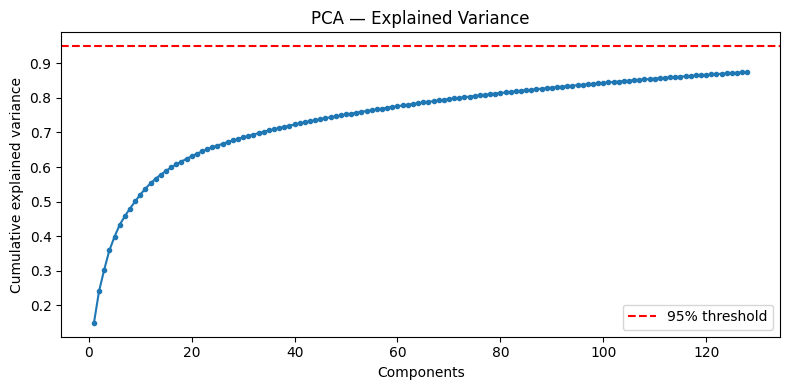

In [6]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_raw)
X_val_sc   = scaler.transform(X_val_raw)
X_test_sc  = scaler.transform(X_test_raw)

pca = PCA(n_components=N_PCA, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_sc)
X_val_pca   = pca.transform(X_val_sc)
X_test_pca  = pca.transform(X_test_sc)

cum_var = np.cumsum(pca.explained_variance_ratio_)
print(f"Variance explained by {N_PCA} components: {cum_var[-1]*100:.1f}%")

plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, N_PCA + 1), cum_var, marker='o', markersize=3)
plt.axhline(0.95, color='r', linestyle='--', label='95% threshold')
plt.xlabel('Components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA — Explained Variance')
plt.legend()
plt.tight_layout()
plt.show()

## 5. SVM Hyperparameter Search
Grid search over `C` and `gamma` with 5-fold stratified CV.
`class_weight='balanced'` automatically compensates for the ~4.7:1 class imbalance.

In [7]:
param_grid = {
    "C":     [0.1, 1, 10, 100],
    "gamma": ["scale", "auto", 0.001, 0.01],
}

cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
svm = SVC(kernel="rbf", class_weight="balanced", random_state=SEED)

grid_search = GridSearchCV(
    svm,
    param_grid,
    cv=cv,
    scoring="f1",          # optimise for fractured class F1
    n_jobs=-1,
    verbose=2,
)
grid_search.fit(X_train_pca, y_train)

print(f"\nBest params : {grid_search.best_params_}")
print(f"Best CV F1  : {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END .................................C=0.1, gamma=scale; total time=   0.3s
[CV] END .................................C=0.1, gamma=0.001; total time=   0.4s
[CV] END .................................C=0.1, gamma=scale; total time=   0.4s
[CV] END .................................C=0.1, gamma=scale; total time=   0.4s
[CV] END .................................C=0.1, gamma=scale; total time=   0.4s
[CV] END .................................C=0.1, gamma=scale; total time=   0.4s
[CV] END .................................C=0.1, gamma=0.001; total time=   0.4s
[CV] END ..................................C=0.1, gamma=auto; total time=   0.4s
[CV] END ..................................C=0.1, gamma=auto; total time=   0.4s
[CV] END ..................................C=0.1, gamma=auto; total time=   0.4s
[CV] END ..................................C=0.1, gamma=auto; total time=   0.4s
[CV] END ..................................C=0.1

## 6. Evaluate Best SVM


Validation Results
               precision    recall  f1-score   support

Non-fractured       0.90      0.84      0.87       385
    Fractured       0.42      0.55      0.48        82

     accuracy                           0.79       467
    macro avg       0.66      0.69      0.67       467
 weighted avg       0.81      0.79      0.80       467



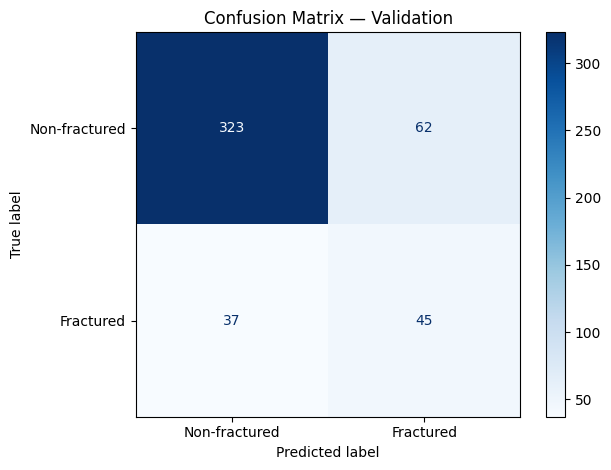


Test Results
               precision    recall  f1-score   support

Non-fractured       0.88      0.83      0.86       286
    Fractured       0.38      0.49      0.43        61

     accuracy                           0.77       347
    macro avg       0.63      0.66      0.64       347
 weighted avg       0.80      0.77      0.78       347



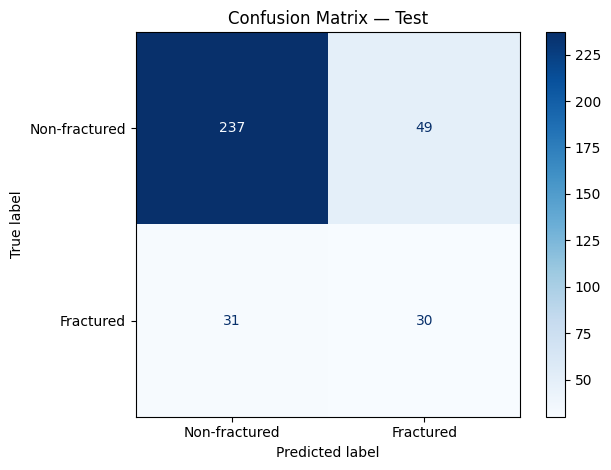

In [8]:
best_svm = grid_search.best_estimator_

for split_name, X, y in [("Validation", X_val_pca, y_val), ("Test", X_test_pca, y_test)]:
    preds = best_svm.predict(X)
    print(f"\n{'='*40}")
    print(f"{split_name} Results")
    print('='*40)
    print(classification_report(y, preds, target_names=["Non-fractured", "Fractured"]))

    cm   = confusion_matrix(y, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Non-fractured", "Fractured"])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix — {split_name}')
    plt.tight_layout()
    plt.show()

## 7. Decision Score Distribution
Shows how confidently the SVM separates the two classes.
Good separation = two distinct peaks far apart.

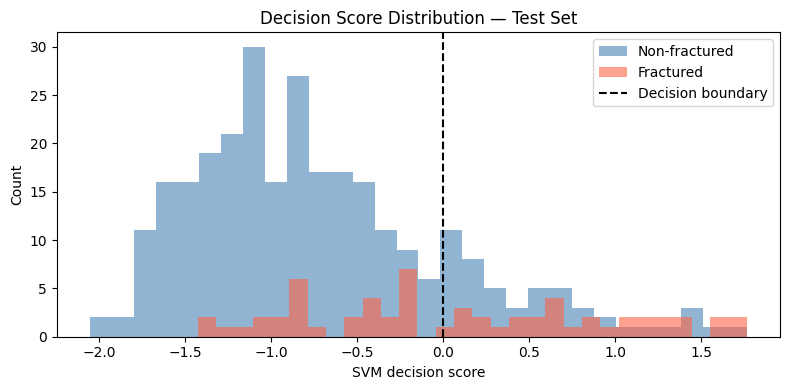

In [9]:
scores = best_svm.decision_function(X_test_pca)

plt.figure(figsize=(8, 4))
plt.hist(scores[y_test == 0], bins=30, alpha=0.6, label='Non-fractured', color='steelblue')
plt.hist(scores[y_test == 1], bins=30, alpha=0.6, label='Fractured',     color='tomato')
plt.axvline(0, color='black', linestyle='--', label='Decision boundary')
plt.xlabel('SVM decision score')
plt.ylabel('Count')
plt.title('Decision Score Distribution — Test Set')
plt.legend()
plt.tight_layout()
plt.show()

## 8. PCA Feature Space Visualisation (Test Set)

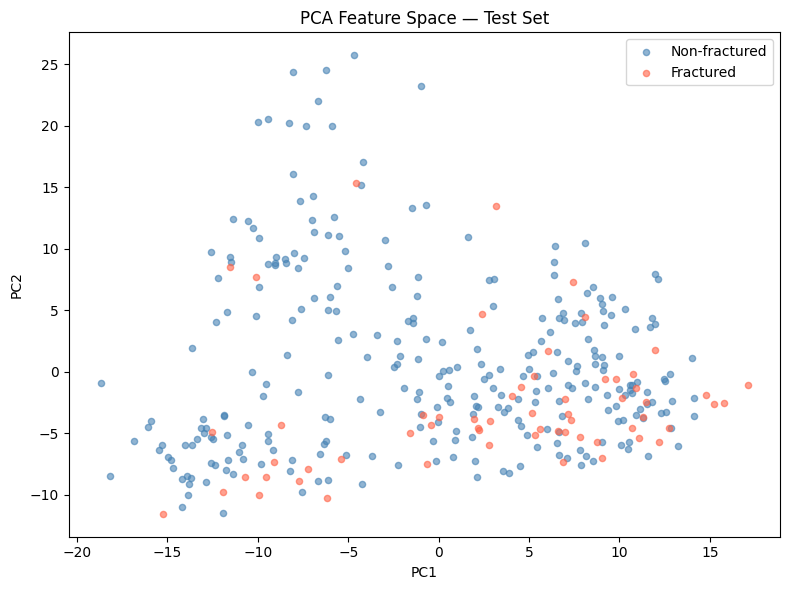

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
colors  = ['steelblue', 'tomato']
labels  = ['Non-fractured', 'Fractured']

for cls in [0, 1]:
    mask = y_test == cls
    ax.scatter(X_test_pca[mask, 0], X_test_pca[mask, 1],
               c=colors[cls], label=labels[cls], alpha=0.6, s=20)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA Feature Space — Test Set')
ax.legend()
plt.tight_layout()
plt.show()